# Homework 2 - Practical component

**IFT 6390 - Fundamentals of Machine Learning**  

Team members:  
- Mathieu Beaudoin
- Philip Bui



## Q1

What is the derivative of the regularization term?

$$\begin{aligned}
R 
:= & \frac{C}{2}\sum_{j'=1}^m||\mathbf{w}^{j'}||_2^2 \\
= & \frac{C}{2}\sum_{j'=1}^m\sum_{k=1}^p w_{k,j'}^2 \\
\Longrightarrow \frac{\partial R}{\partial w_{k, j}}
=& \frac{\partial}{\partial w_{k, j}}\frac{C}{2}\sum_{j'=1}^m||\mathbf{w}^{j'}||_2^2 \\
=& \frac{C}{2}\sum_{j'=1}^m\frac{\partial}{\partial w_{k, j}}||\mathbf{w}^{j'}||_2^2 \\
=& \frac{C}{2}\sum_{j'=1}^m\frac{\partial}{\partial w_{k, j}}\sum_{h=1}^p w_{h,j'}^2 \\
=& \frac{C}{2}\sum_{j'=1}^m\sum_{h=1}^p \frac{\partial w_{h,j'}^2}{\partial w_{k, j}} \\
=& Cw_{k,j} \\
\Longrightarrow \nabla_{\mathbf{w}}R
=& C\mathbf{w}
\end{aligned}$$

## Q2
What is the derivative of the hinge loss term?  

**Notation**:  

- Indices:
  - Observations: $i\in\{1,...,n\}$
  - Features: $k\in\{1,...,d\}$
  - Classes: $j\in\{1,...,m\}$
- $X\in\mathbb{R}^{n\times d}$ is our data matrix
  - If noted with a single index ($X_i$), represents the feature (row) $d$-vector of observation $i$
- $y\in\mathbb{N}^{n}$ is our raw label vector
- $\mathbf{w}\in\mathbb{R}^{d\times m}$ is our model weights matrix
- $\mathcal{I}$ represents the set of observation indices associated to a mini-batch

**Basic transformations**:

- $Y\in\{-1,+1\}^{n\times m}$ is our transformed label matrix
  - If noted with a single index ($Y_i$), represents the label (row) $m$-vector for observation $i$
- $\Theta\in\mathbb{R}^{n\times m}$ is the scores matrix: $\Theta:=X\mathbf{w}$
- $\xi:=Y\odot\Theta$ provides a shorthand for the element-wise multiplication of our $Y$ and $\Theta$ matrices, which we will use repeatedly.  


We have:
$$L:=\frac{1}{n}\sum_{i\in\mathcal{I}} \sum_{j=1}^{m} \mathcal{L}(\mathbf{w}_j; (X_i, Y_i))$$
with
$$\begin{aligned}
\mathcal{L}(\mathbf{w}_j; (X_i, Y_i))
:=& \Big(\max\big\{0,\ 2- \langle\mathbf{w}_j, X_i\rangle \cdot Y_{i,j} \big\}\Big)^2\\
=& \Big(\max\big\{0,\ 2- \Theta_{i,j}Y_{i,j} \big\}\Big)^2 \\
=& \mathbb{I}\{\Theta_{i,j}Y_{i,j}\le2\}\cdot(2 - \Theta_{i,j}Y_{i,j})^2 \\
=& \mathbb{I}\{\xi_{i,j}\le2\}\cdot(2 - \xi_{i,j})^2
\end{aligned}$$
where $\mathbb{I}\{A\}$ is one if $A$ is true, zero otherwise.  

Since the derivative of the $\mathbb{I}$ term is zero everywhere (except where $\xi_{i,j}=2$, in which case the derivative is not undefined), the partial derivative of a single observation's loss with respect to a single parameter of the weights matrix if quite straightforward to compute:
$$\begin{aligned}
n\cdot\frac{\partial L_i}{\partial \mathbf{w}_{k,j}}
&= \frac{\partial}{\partial \mathbf{w}_{k,j}} \mathbb{I}\{\xi_{i,j}\le2\}\cdot(2 - \xi_{i,j})^2 \\
&= \mathbb{I}\{\xi_{i,j}\le2\}\cdot\frac{\partial}{\partial \mathbf{w}_{k,j}}(2 - \xi_{i,j})^2 \\
&= \mathbb{I}\{\xi_{i,j}\le2\}\cdot2(2 - \xi_{i,j})\frac{\partial}{\partial \mathbf{w}_{k,j}}(-\xi_{i,j}) \\
&= 2\mathbb{I}\{\xi_{i,j}\le2\}(2 - \xi_{i,j})\frac{\partial}{\partial \mathbf{w}_{k,j}}(-\Theta_{i,j}Y_{i,j}) \\
&= -2Y_{i,j}\mathbb{I}\{\xi_{i,j}\le2\}(2 - \xi_{i,j})
\frac{\partial}{\partial \mathbf{w}_{k,j}}\langle\mathbf{w}_j, X_i\rangle \\
&= -2Y_{i,j}\mathbb{I}\{\xi_{i,j}\le2\}(2 - \xi_{i,j})X_{i,k}
\end{aligned}$$

### Vector/matrix representation

Although this was not explicitly asked in the question statement, let us build a vector/matrix representation of the gradient, to show the steps between what we already have and what we'll actually use when implementing the gradient computation in the code.  

We seek a $(d\times m)$ matrix of the loss gradient with respect to the model weights, which we will call $\nabla_{\mathbf{w}}L$.  

Starting from the scalar expression we found above, we notice that most of it is independent from the feature index $k$, so the most obvious step from here is to expand the expression to the row vector for weights associated to feature $k$, giving us a $(1\times m)$ vector:
$$n\nabla_{\mathbf{w_k}}L_i 
= -2X_{i,k}\big[Y_i\odot\mathbb{I}\{\xi_i\le2\}\odot(2 - \xi_i)\big]$$
To ease notation, we define:
$$\Psi_i:=Y_i\odot\mathbb{I}\{\xi_i\le2\}\odot(2 - \xi_i)\quad\in\mathbb{R}^{1\times m}$$
From here, we can get the $(d\times m)$ gradient matrix for the loss associated to observation $i$ with a simple outer product:
$$n\nabla_{\mathbf{w}}L_i=-2X_i^\top\Psi_i$$
By dropping the $i$ indices from each term, $X^\top$ becomes a $(d\times n)$ matrix and $\Psi$ a $(n\times m)$ matrix, meaning both terms are compatible and will sum over the entire sample:
$$\nabla_{\mathbf{w}}L=-\frac{2}{n}X^\top\Psi$$
and voilà!

## Q4: Learning plots

Loading data...
Training model with C=1.0
Training model with C=5.0
Training model with C=10.0


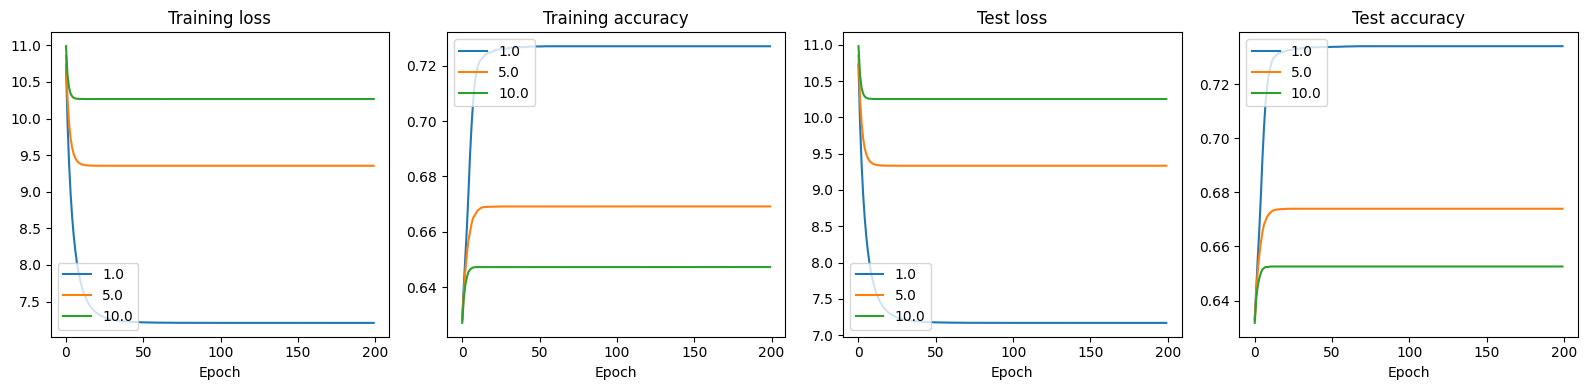

In [2]:
from solution import load_data
from plots import plot_learning
data = load_data()
plot_learning([1., 5., 10.], data=data)

Clearly, overfitting is **not** a major concern with this data: training and test accuracies are very similar (while developing this functionality, we felt the need to validate that the accuracy and loss vectors plotted were actually distinct!), and lower regularization coefficients produce better results.   

Although this was not asked in the problem statement, let us see if our previous observation breaks down if we drastically reduce, or even eliminate, the regularization term:

Training model with C=0
Training model with C=0.05
Training model with C=0.1


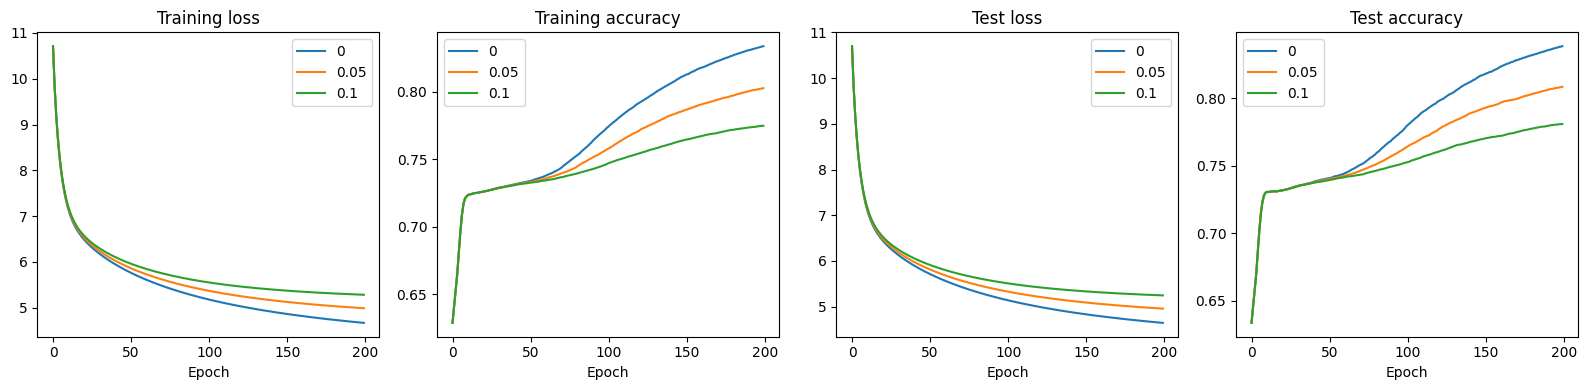

In [4]:
plot_learning([0, .05, .1], data=data)

The best *test* performance was obtained by completely discarding the regularization term. This means that our main worry with this model should be *under*fitting rather than overfitting!